<!-- NINO26-CABECALHO v1 -->
# 3E — Sensibilidade temporal sem breakpoint pré-fixado

**Projeto NINO-BRASIL — Oceanografia Física UFPE — Thiago Vilar**  
**Código da fase/letra:** `3E`  ·  **Hipótese:** HIP0

## Descritivo (por que este notebook existe)
Quantifica quanto os achados dependem de eventos individuais e da autocorrelação, sem impor regimes artificiais — a defesa contra conclusões dominadas por poucos eventos.

## Pergunta
Quanto as correlações que sobreviveram ao 3D dependem de eventos ENSO individuais e da estrutura autocorrelacionada?

## Desafio (hipótese a testar)
A unidade de incerteza deve ser o evento, não a semana; nenhum corte temporal fixo (ex.: 1993/2010) pode entrar como filtro.

## Metodologia (com referências)
Bootstrap em blocos e leave-one-event-out, com envelope de IC e fração de mesmo sinal (validação para dados dependentes — Roberts et al., 2017; Wilks, 2016).

## Contrato de saídas — código predecessor único
Cada figura nasce do **mesmo** `registrar_figura(...)` que congela sua numeric-table sob o **mesmo código**, reescrevendo por **sobreposição** a cada execução. A fonte deve ser uma tabela persistida com sidecar e hash do mesmo `run_id`:

```python
from nino_brasil.viz import registrar_figura
registrar_figura(fig, "Fig_3E01", fase=3, bloco="E",
                 titulo=..., descricao=..., hipotese="HIP0",
                 notebook="notebooks/fase3/3E_sensibilidade_temporal.ipynb",
                 run_id=run.run_id,
                 fontes={"<tabela>": tabela_path})   # Path + .manifest.json -> figures/fase3/<codigo>.png + numeric-tables/fase3/<codigo>/
```

| Código | Figura (`figures/fase3/<código>.png`) | Numeric-table (`numeric-tables/fase3/<código>/`) | Descrição |
|---|---|---|---|
| `Fig_3E01` | `Fig_3E01.png` | `Fig_3E01/` | sensibilidade bootstrap/LOO |
| `Fig_3E02` | `Fig_3E02.png` | `Fig_3E02/` | influência de cada evento (LOO) |

> Padrão em `docs/PADRAO_NOTEBOOKS.md`; compatibilidade por `python scripts/validar_figuras.py --strict --allow-render-extraction`; promoção por `python scripts/validar_figuras.py --strict`.

## Contrato científico central

As tabelas abaixo são geradas pelo executor F3 testado. Rótulos de fase/faixa de pico são retrospectivos; previsão usa apenas a tabela rolling-origin. O evento é a unidade independente.


In [1]:
from pathlib import Path
import json, os, subprocess, sys
import pandas as pd
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'pyproject.toml').exists())
PYTHON = sys.executable
MODE = os.environ.get('NINO26_NOTEBOOK_MODE', 'smoke')
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
assert MODE in {'smoke', 'official'}
print({'root': str(ROOT), 'python': PYTHON, 'mode': MODE, 'run_pipeline': RUN_PIPELINE})

ENSO_TYPE = os.environ.get('NINO26_ENSO_TYPE', '').strip()
assert ENSO_TYPE in {'', 'el_nino', 'la_nina'}
STATS = Path(os.environ.get('NINO26_PHASE3_STATS_DIR', ROOT/'data/processed/parquet/statistics'))


{'root': 'C:\\DEV\\NINO26', 'python': 'C:\\DEV\\NINO26\\.venv\\Scripts\\python.exe', 'mode': 'official', 'run_pipeline': False}


In [2]:
if RUN_PIPELINE:
    command=[PYTHON, str(ROOT/'scripts/phase3_en_ln.py')]
    if ENSO_TYPE: command.extend(['--enso-type', ENSO_TYPE])
    if MODE == 'smoke': command.append('--quick')
    subprocess.run(command, cwd=ROOT, check=True)


,table,exists,manifest
0,phase3_lag_event_bootstrap_summary.csv,True,True
1,phase3_lag_event_bootstrap_replicates.csv,True,True
2,phase3_best_lags_fdr.csv,True,True


phase3_lag_event_bootstrap_summary.csv


,tipo,fase,variavel_alvo,n_precursores_candidatos,aliases_alvo_excluidos,bootstrap_screening_rank,bootstrap_screening_top_k,bootstrap_screening_rule,lag_semanas,n_eventos_independentes,...,vezes_selecionado,frequencia_selecao,r_mediano_quando_selecionado,r_ic95_inf_quando_selecionado,r_ic95_sup_quando_selecionado,resampling_unit,lag_selection_repeated_inside_bootstrap,condition_time,variavel,n_precursores_fdr_na_familia
0,el_nino,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,0,11,...,996,0.996,0.857144,0.685272,0.928246,evento_enso_completo,True,source,t50m,14
1,el_nino,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,1,11,...,0,0.000,NaN,NaN,NaN,evento_enso_completo,True,source,t50m,14
2,el_nino,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,2,11,...,0,0.000,NaN,NaN,NaN,evento_enso_completo,True,source,t50m,14
3,el_nino,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,3,11,...,0,0.000,NaN,NaN,NaN,evento_enso_completo,True,source,t50m,14
4,el_nino,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,4,11,...,0,0.000,NaN,NaN,NaN,evento_enso_completo,True,source,t50m,14
5,el_nino,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,5,11,...,0,0.000,NaN,NaN,NaN,evento_enso_completo,True,source,t50m,14
6,el_nino,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,6,11,...,0,0.000,NaN,NaN,NaN,evento_enso_completo,True,source,t50m,14
7,el_nino,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,7,11,...,0,0.000,NaN,NaN,NaN,evento_enso_completo,True,source,t50m,14
8,el_nino,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,8,11,...,0,0.000,NaN,NaN,NaN,evento_enso_completo,True,source,t50m,14
9,el_nino,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,9,11,...,2,0.002,0.924094,0.917155,0.931033,evento_enso_completo,True,source,t50m,14


phase3_lag_event_bootstrap_replicates.csv


,bootstrap_replicate,variavel_alvo,n_precursores_candidatos,aliases_alvo_excluidos,bootstrap_screening_rank,bootstrap_screening_top_k,bootstrap_screening_rule,lag_selecionado_semanas,r_selecionado,n_pares,eventos_amostrados,tipo,fase,variavel,n_precursores_fdr_na_familia
0,0,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,0,0.873014,147,el_nino_1994_1995|el_nino_2009_2010|el_nino_19...,el_nino,crescimento,t50m,14
1,1,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,0,0.774380,241,el_nino_1986_1988|el_nino_1994_1995|el_nino_20...,el_nino,crescimento,t50m,14
2,2,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,0,0.897939,192,el_nino_1982_1983|el_nino_1997_1998|el_nino_20...,el_nino,crescimento,t50m,14
3,3,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,0,0.899884,171,el_nino_1997_1998|el_nino_1997_1998|el_nino_19...,el_nino,crescimento,t50m,14
4,4,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,0,0.911350,282,el_nino_2018_2019|el_nino_2014_2016|el_nino_20...,el_nino,crescimento,t50m,14
5,5,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,0,0.861822,322,el_nino_1997_1998|el_nino_1997_1998|el_nino_20...,el_nino,crescimento,t50m,14
6,6,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,0,0.849080,328,el_nino_1986_1988|el_nino_2014_2016|el_nino_20...,el_nino,crescimento,t50m,14
7,7,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,0,0.776226,238,el_nino_2018_2019|el_nino_2018_2019|el_nino_20...,el_nino,crescimento,t50m,14
8,8,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,0,0.869844,259,el_nino_1982_1983|el_nino_1997_1998|el_nino_19...,el_nino,crescimento,t50m,14
9,9,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,0,0.825483,240,el_nino_2018_2019|el_nino_1986_1988|el_nino_20...,el_nino,crescimento,t50m,14


phase3_best_lags_fdr.csv


,tipo,fase,variavel,variavel_alvo,n_precursores_candidatos,aliases_alvo_excluidos,precursor_screening_policy,lag_semanas,r_pearson,n_pares,...,evaluation_mode,q_fdr_bh,significativo_fdr,field_p_simes,campo_significativo,field_test_method,field_test_assumption,rank_abs_r_na_familia,selection_rule,lag_selected_after_fdr
0,el_nino,genese,ohc_0_100,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,0,0.804677,295,...,diagnostico_retrospectivo_inferencial,0.001422,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,2.0,max_abs_r_entre_lags_significativos_fdr,True
1,el_nino,genese,ohc_0_300,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,5,0.568895,295,...,diagnostico_retrospectivo_inferencial,0.024383,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,34.0,max_abs_r_entre_lags_significativos_fdr,True
2,el_nino,genese,ohc_0_700,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,5,0.518256,295,...,diagnostico_retrospectivo_inferencial,0.038832,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,69.0,max_abs_r_entre_lags_significativos_fdr,True
3,el_nino,genese,ssh_m,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,2,0.596241,295,...,diagnostico_retrospectivo_inferencial,0.017419,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,25.0,max_abs_r_entre_lags_significativos_fdr,True
4,el_nino,genese,t50m,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,0,0.804810,295,...,diagnostico_retrospectivo_inferencial,0.001422,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,1.0,max_abs_r_entre_lags_significativos_fdr,True
5,el_nino,genese,t100m,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,1,0.630393,295,...,diagnostico_retrospectivo_inferencial,0.018187,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,16.0,max_abs_r_entre_lags_significativos_fdr,True
6,el_nino,genese,tau_x_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,2,0.250282,295,...,diagnostico_retrospectivo_inferencial,0.025986,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,480.0,max_abs_r_entre_lags_significativos_fdr,True
7,el_nino,genese,u10_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,2,0.279076,295,...,diagnostico_retrospectivo_inferencial,0.012939,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,407.0,max_abs_r_entre_lags_significativos_fdr,True
8,el_nino,genese,mslp_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,10,-0.231820,295,...,diagnostico_retrospectivo_inferencial,0.026370,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,536.0,max_abs_r_entre_lags_significativos_fdr,True
9,el_nino,genese,tcwv_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,0,0.384122,295,...,diagnostico_retrospectivo_inferencial,0.012837,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,218.0,max_abs_r_entre_lags_significativos_fdr,True


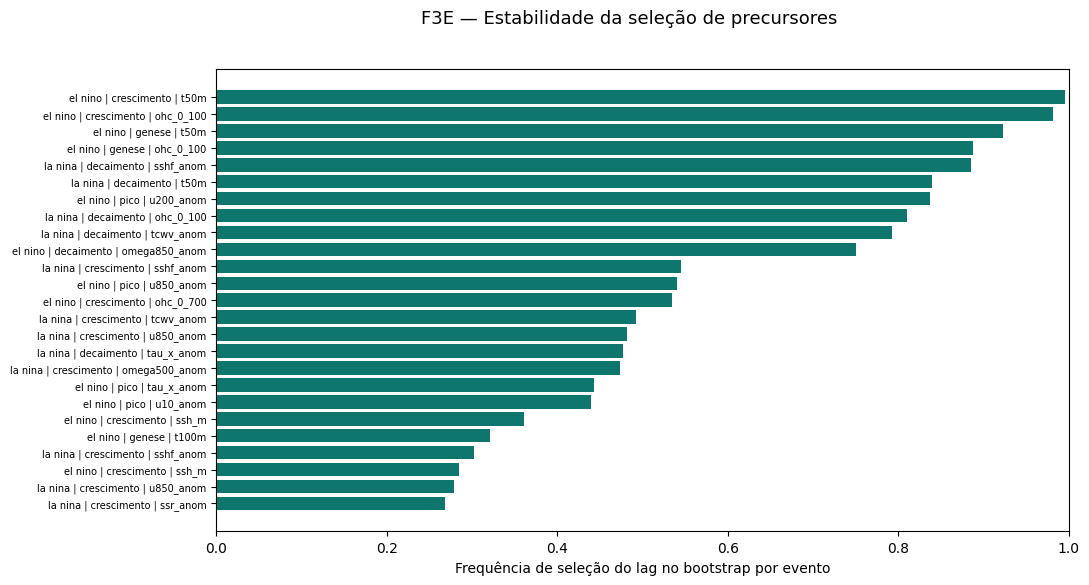

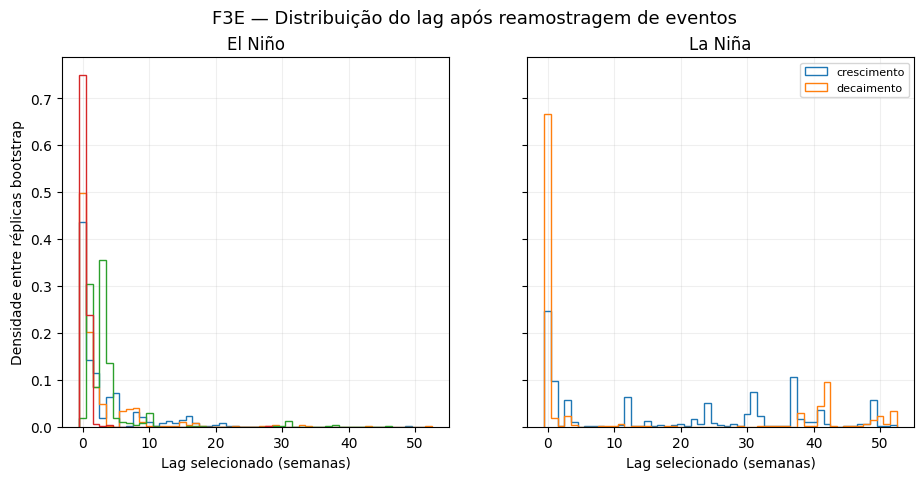

In [3]:
table_names=['phase3_lag_event_bootstrap_summary.csv', 'phase3_lag_event_bootstrap_replicates.csv', 'phase3_best_lags_fdr.csv']
base = STATS/'pilots/quick' if MODE == 'smoke' else STATS
inventory=[]
for name in table_names:
    path=base/name
    inventory.append({'table':name,'exists':path.exists(),'manifest':path.with_suffix(path.suffix+'.manifest.json').exists()})
display(pd.DataFrame(inventory))
for name in table_names:
    path=base/name
    if path.exists():
        print(name); display(pd.read_csv(path).head(30))

sys.path.insert(0, str(ROOT/'scripts'))
from render_phase3_semantic_summaries import render_block
render_block('E')


## Interpretação permitida

`diagnostico_retrospectivo` descreve gênese/crescimento/faixa de pico/decaimento após o evento. `rolling_origin_operacional` mede previsão. Resultados alinhados ao pico conhecido não são hindcasts operacionais.


<!-- NINO26-REFERENCIAS v1 -->
## Referências Bibliográficas

1. Roberts, D. R., et al. (2017). Cross-validation strategies for data with temporal/spatial/hierarchical structure. *Ecography*, 40, 913-929. https://doi.org/10.1111/ecog.02881
2. Wilks, D. S. (2016). 'The Stippling Shows Statistically Significant Grid Points'. *BAMS*, 97, 2263-2273. https://doi.org/10.1175/BAMS-D-15-00267.1

Relação completa em `Artigos_Referências/Referências_Bibliográficas.xls`.